In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd

from load import load_trace
from stats import retry_distribution, size_bucket_stats, percentile_table, residual_stats
from plot import plot_retries_vs_size, plot_retry_histogram, plot_residual_vs_size, plot_time_vs_size, plot_size_cdf, plot_time_breakdown

## Load Trace Data
Point this to the `mphf_trace.jsonl` produced by `build-hcltj`.

In [3]:
trace_path = Path("../../data/nightly/premix32-threshold4000/mphf_trace.jsonl")
df = load_trace(trace_path)
print(f"Loaded {len(df):,} nodes.")
df.head()

Loaded 7,931 nodes.


,trie_id,node_pos,n_children,threshold,success,retries_used,best_failed_residual,worst_failed_residual,best_peeled_frac,total_elapsed_ms
0,0,0,106829756,4000,False,10,112,216622,0.999999,1.995640e+07
1,0,739018991,6655,4000,True,0,0,0,1.000000,7.713640e+01
2,1,48933953,6687,4000,True,0,0,0,1.000000,9.185040e+00
3,2,0,5387,4000,True,0,0,0,1.000000,6.824830e+00
4,2,5975,23783395,4000,True,1,6,6,1.000000,1.042080e+05


## Retry Distribution
How many attempts does it take to peel the hypergraph?

In [4]:
retry_distribution(df)

,retries_used,n_nodes,pct,cumulative_pct
0,0,7920,99.861304,99.861304
1,1,8,0.100870,99.962174
2,5,1,0.012609,99.974782
3,10,2,0.025218,100.000000


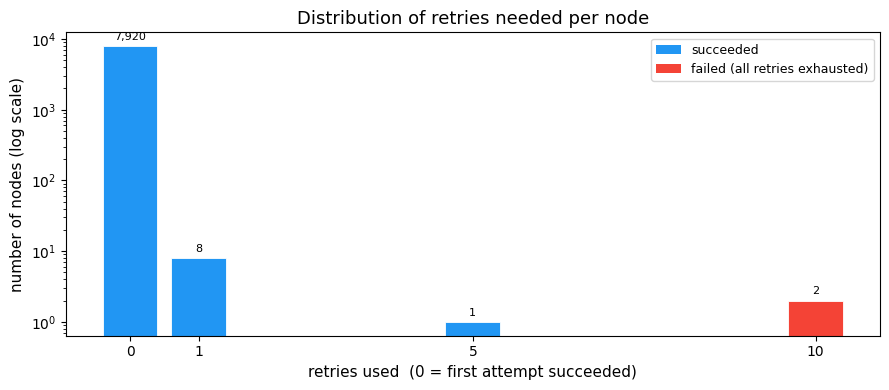

In [6]:
plot_retry_histogram(df);

## Stats by Node Size
Are larger nodes harder to peel?

In [7]:
size_bucket_stats(df)

,size_bucket,n_nodes,n_success,n_first_try,mean_retries,max_retries,total_time_s,success_rate_pct,first_try_rate_pct
0,<10K,4645,4645,4639,0.001292,1,31.304774,100.000000,99.870829
1,10K–100K,2957,2957,2957,0.000000,0,95.577150,100.000000,100.000000
2,100K–1M,289,289,289,0.000000,0,138.839366,100.000000,100.000000
3,1M–10M,29,28,28,0.344828,10,149.361580,96.551724,96.551724
4,10M–100M,10,10,7,0.700000,5,1239.593800,100.000000,70.000000
5,>100M,1,0,0,10.000000,10,19956.400000,0.000000,0.000000


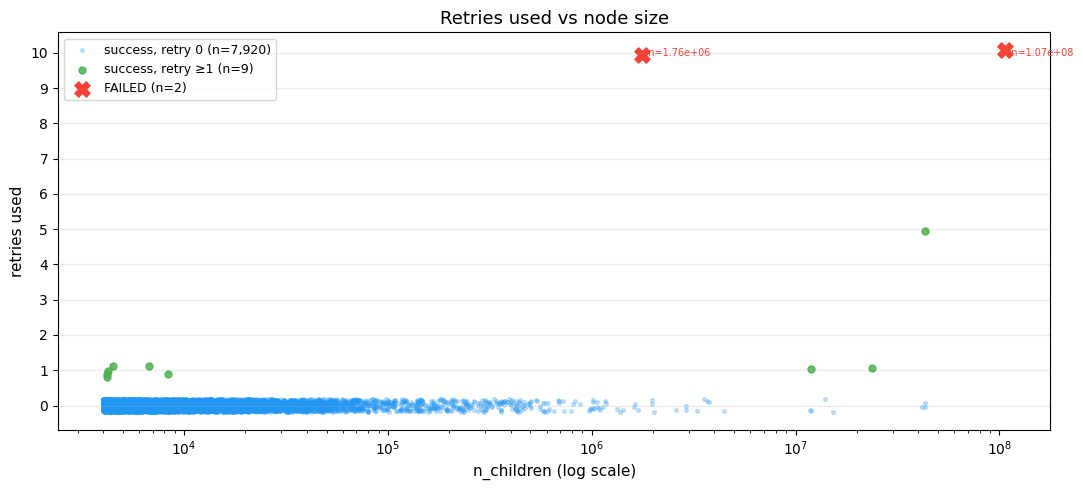

In [8]:
plot_retries_vs_size(df);

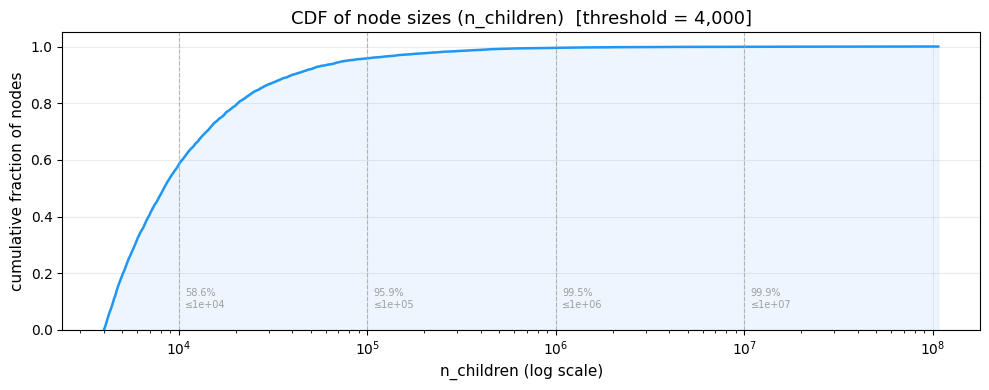

In [9]:
plot_size_cdf(df);

## Residual Analysis
For nodes that fail to peel, how large is the remaining 2-core? This informs the viability of the Fallback system.

In [10]:
partial = residual_stats(df)
partial.head(20)

,trie_id,node_pos,n_children,success,retries_used,best_failed_residual,worst_failed_residual,best_peeled_frac,total_elapsed_ms
0,0,0,106829756,False,10,112,216622,0.999999,1.995640e+07
1,2,66894266,43102396,True,5,6,32,1.000000,5.741380e+05
2,2,5975,23783395,True,1,6,6,1.000000,1.042080e+05
3,2,195609076,11900539,True,1,6,6,0.999999,5.065100e+04
4,2,976684479,1758754,False,10,2,2,0.999999,3.449000e+04
5,2,674062665,8372,True,1,3229,3229,0.614310,1.149350e+01
6,2,156965102,6690,True,1,2446,2446,0.634380,9.516040e+00
7,2,524761317,4474,True,1,1857,1857,0.584935,8.192790e+00
8,2,761425331,4234,True,1,1475,1475,0.651630,7.547000e+00
9,2,960018079,4181,True,1,1590,1590,0.619708,7.423120e+00


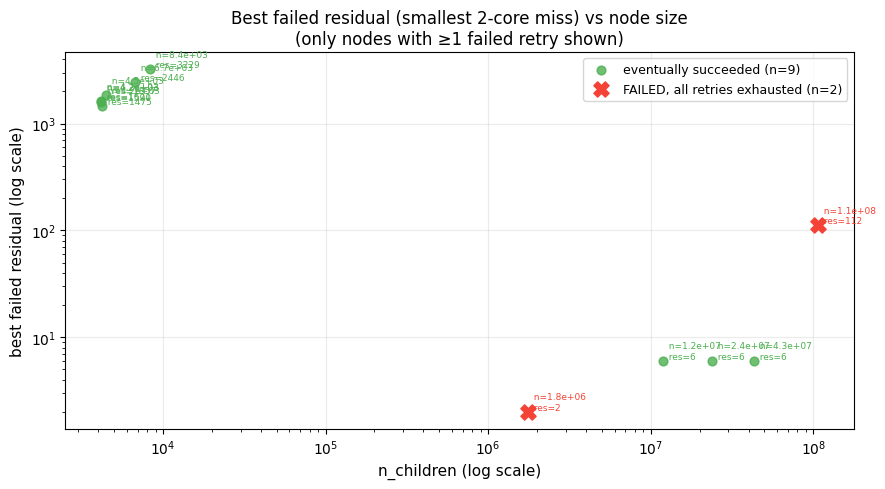

In [11]:
if not partial.empty:
    plot_residual_vs_size(df);

## Build Time Analysis
Where does the wall-clock time go during construction?

In [12]:
percentile_table(df)

,percentile,n_children,elapsed_s
0,p50,8.316000e+03,0.008184
1,p75,1.675750e+04,0.019523
2,p90,3.998900e+04,0.055377
3,p95,7.786350e+04,0.126876
4,p99,4.410551e+05,0.851979
5,p99.9,1.204515e+07,34.548352
6,p100,1.068298e+08,19956.400000


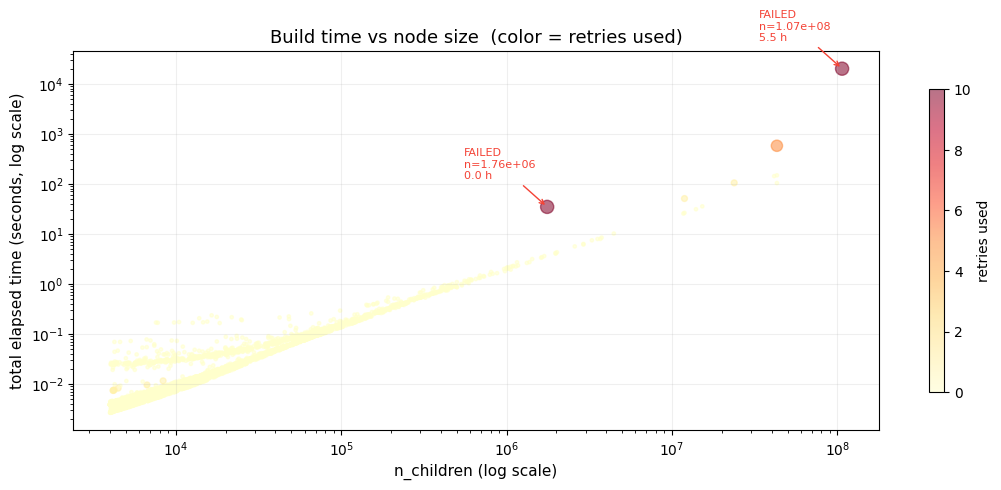

In [13]:
plot_time_vs_size(df);

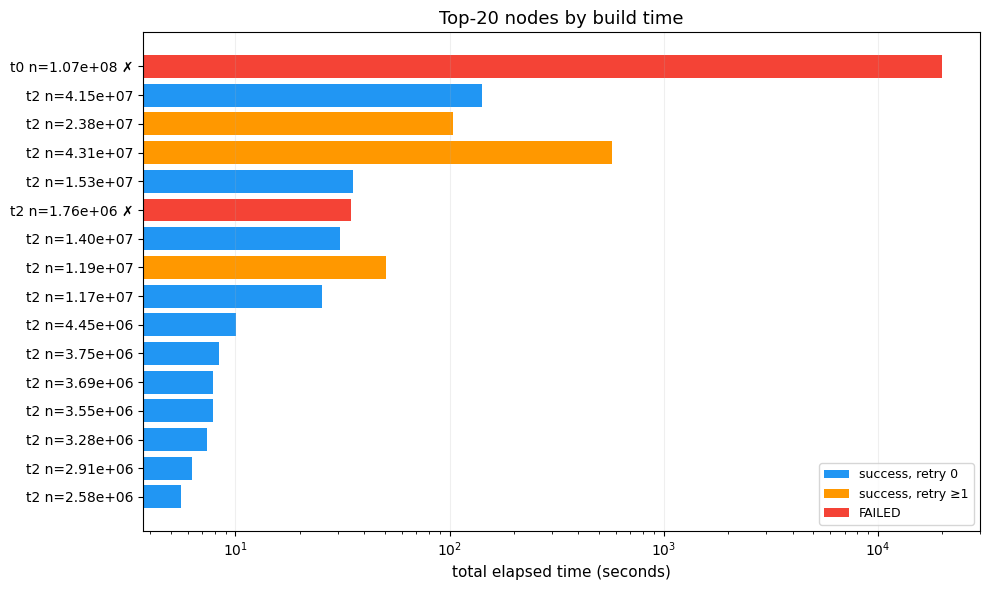

In [14]:
plot_time_breakdown(df);